In [54]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [55]:
#POINTS = np.array([(10, 10), (20, 10)]) # Tuple of (bins, pulls) points
POINTS = np.array([(50, 10), (75, 10), (100, 10), (125, 10), (150, 10), (175, 10), (200, 10), (225, 10), (250, 10), (275, 10), 
                   (300, 10), (325, 10), (350, 10), (375, 10), (400, 10), (425, 10), (450, 10), (475, 10), (500, 10)])

In [56]:
process_times = np.array([])
fill_spectra_all_times = np.array([])
fill_spectra_phys_times = np.array([])
fill_spectra_nuis_times = np.array([])
chi2_times = np.array([])
chi2_with_grad_times = np.array([])

for bins, pulls in POINTS:
    with open(f'./scaling_outputs/scale_{bins}bins_{pulls}pulls.txt', 'r') as f:
        lines = f.readlines()
        for line in lines:
            if 'fillspectra_vary_all' in line:
                line_arr = line.split()
                time = float(line_arr[-1].split('=')[-1])
                fill_spectra_all_times = np.append(fill_spectra_all_times, time)
            elif 'fillspectra_vary_phys' in line:
                line_arr = line.split()
                time = float(line_arr[-1].split('=')[-1])
                fill_spectra_phys_times = np.append(fill_spectra_phys_times, time)
            elif 'fillspectra_vary_nuis' in line:
                line_arr = line.split()
                time = float(line_arr[-1].split('=')[-1])
                fill_spectra_nuis_times = np.append(fill_spectra_nuis_times, time)
            elif 'metric_vary_all' in line:
                line_arr = line.split()
                time = float(line_arr[-1].split('=')[-1])
                chi2_times = np.append(chi2_times, time)
            elif 'metric_grad_vary_all' in line:
                line_arr = line.split()
                time = float(line_arr[-1].split('=')[-1])
                chi2_with_grad_times = np.append(chi2_with_grad_times, time)
    f.close()

    with open(f'./time_logs/user_{bins}bins_{pulls}pulls_time.txt', 'r') as f2:
        line = f2.readline()
        time = float(line.split()[1].split('m')[0]) * 60 + float(line.split()[1].split('m')[1].split('s')[0])
        process_times = np.append(process_times, time)
    f2.close()

In [57]:
def exponential_func(x, a, b):
    return a * np.exp(b * x)

def quadratic_func(x, a, b, c):
    return a * x**2 + b * x + c

params_exp, covar_exp = curve_fit(exponential_func, POINTS[:, 0], fill_spectra_all_times, p0=(100, 0.006))
exp_residuals = fill_spectra_all_times - exponential_func(POINTS[:, 0], *params_exp)
exp_ss_res = np.sum(exp_residuals**2)
exp_ss_tot = np.sum((fill_spectra_all_times - np.mean(fill_spectra_all_times))**2)
exp_r_squared = 1 - (exp_ss_res / exp_ss_tot)

params_quad, covar_quad = curve_fit(quadratic_func, POINTS[:, 0], fill_spectra_all_times)
quad_residuals = fill_spectra_all_times - quadratic_func(POINTS[:, 0], *params_quad)
quad_ss_res = np.sum(quad_residuals**2)
quad_ss_tot = np.sum((fill_spectra_all_times - np.mean(fill_spectra_all_times))**2)
quad_r_squared = 1 - (quad_ss_res / quad_ss_tot)

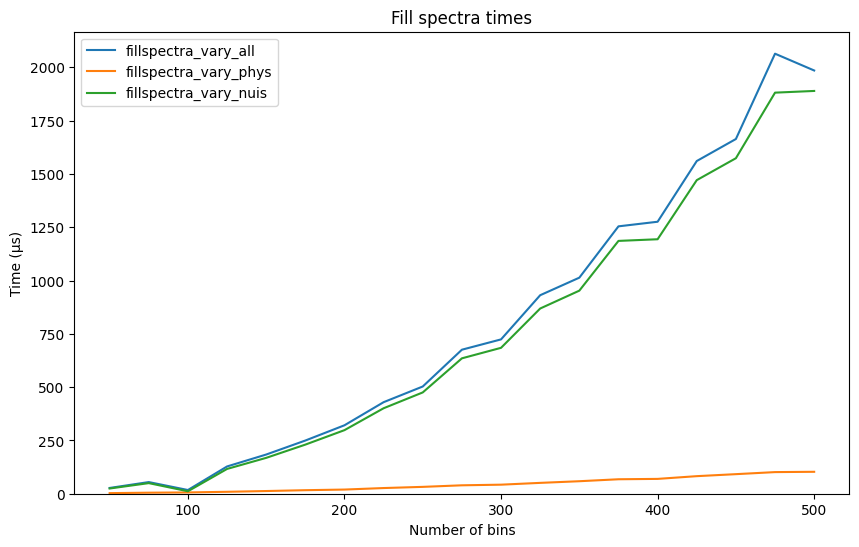

In [58]:
plt.figure(figsize=(10, 6))
plt.plot(POINTS[:, 0], fill_spectra_all_times, label='fillspectra_vary_all')
plt.plot(POINTS[:, 0], fill_spectra_phys_times, label='fillspectra_vary_phys')
plt.plot(POINTS[:, 0], fill_spectra_nuis_times, label='fillspectra_vary_nuis')
plt.legend()
plt.xlabel('Number of bins')
plt.ylabel('Time (μs)')
plt.title('Fill spectra times')
plt.ylim(0,)
plt.show()

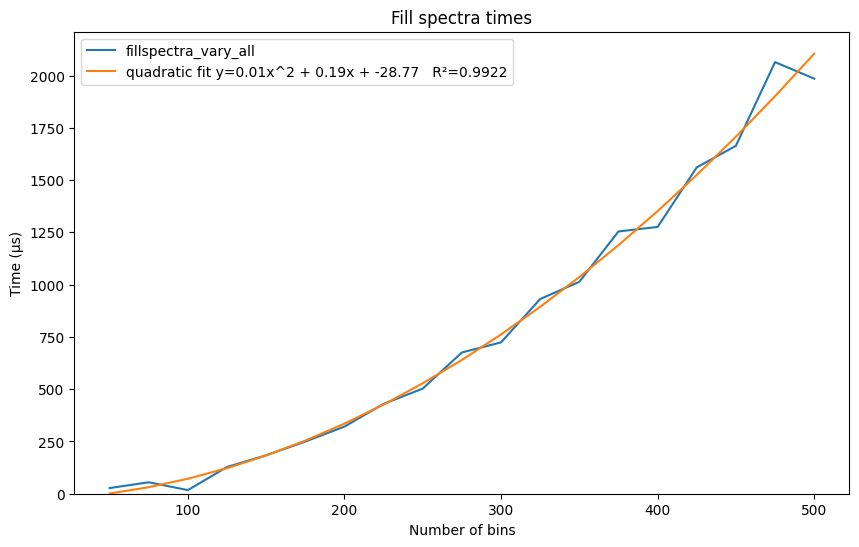

In [59]:
plt.figure(figsize=(10, 6))
plt.plot(POINTS[:, 0], fill_spectra_all_times, label='fillspectra_vary_all')
#plt.plot(POINTS[:, 0], exponential_func(POINTS[:, 0], *params_exp), label='exponential fit y=%.2fe^(%.4fx)        R²=%.4f' % (*tuple(params_exp), exp_r_squared))
plt.plot(POINTS[:, 0], quadratic_func(POINTS[:, 0], *params_quad), label='quadratic fit y=%.2fx^2 + %.2fx + %.2f   R²=%.4f' % (*tuple(params_quad), quad_r_squared))
plt.legend()
plt.xlabel('Number of bins')
plt.ylabel('Time (μs)')
plt.title('Fill spectra times')
plt.ylim(0,)
plt.show()

In [60]:
chi_quad_params, chi_covar_quad = curve_fit(quadratic_func, POINTS[:, 0], chi2_with_grad_times)
chi_quad_residuals = chi2_with_grad_times - quadratic_func(POINTS[:, 0], *chi_quad_params)
chi_quad_ss_res = np.sum(chi_quad_residuals**2)
chi_quad_ss_tot = np.sum((chi2_with_grad_times - np.mean(chi2_with_grad_times))**2)
chi_quad_r_squared = 1 - (chi_quad_ss_res / chi_quad_ss_tot)

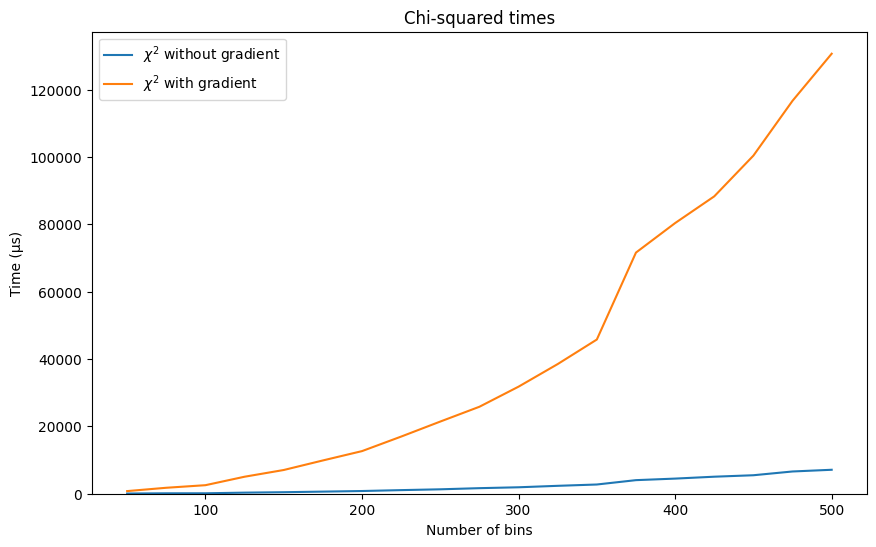

In [61]:
plt.figure(figsize=(10, 6))
plt.plot(POINTS[:, 0], chi2_times, label='$\\chi^2$ without gradient')
plt.plot(POINTS[:, 0], chi2_with_grad_times, label='$\\chi^2$ with gradient')
plt.legend()
plt.xlabel('Number of bins')
plt.ylabel('Time (μs)')
plt.title('Chi-squared times')
plt.ylim(0,)
plt.show()

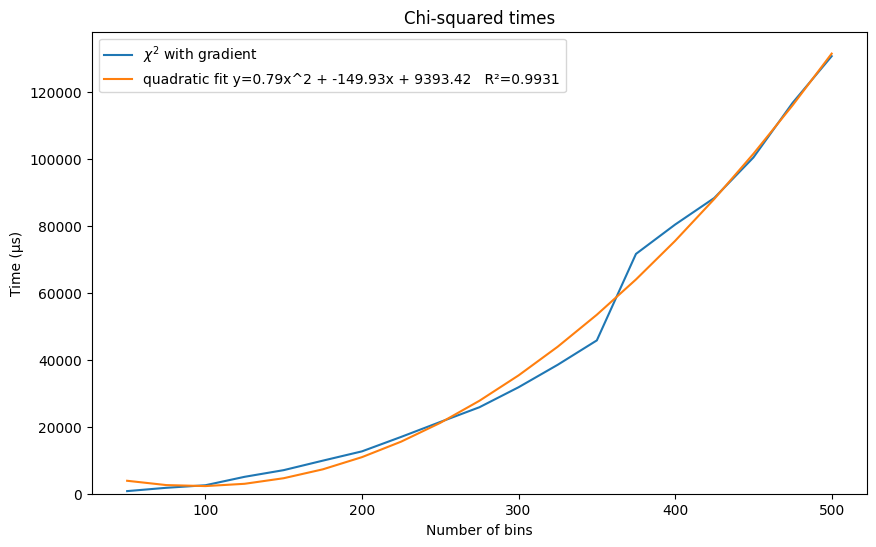

In [62]:
plt.figure(figsize=(10, 6))
plt.plot(POINTS[:, 0], chi2_with_grad_times, label='$\\chi^2$ with gradient')
plt.plot(POINTS[:, 0], quadratic_func(POINTS[:, 0], *chi_quad_params), label='quadratic fit y=%.2fx^2 + %.2fx + %.2f   R²=%.4f' % (*tuple(chi_quad_params), chi_quad_r_squared))
plt.legend()
plt.xlabel('Number of bins')
plt.ylabel('Time (μs)')
plt.title('Chi-squared times')
plt.ylim(0,)
plt.show()

In [63]:
def sqrt_func(x, a, b):
    return a * np.sqrt(x) + b

def log_func(x, a, b):
    return a * np.log(x) + b

sqrt_params, sqrt_covar = curve_fit(sqrt_func, POINTS[:, 0], process_times)
sqrt_residuals = process_times - sqrt_func(POINTS[:, 0], *sqrt_params)
sqrt_ss_res = np.sum(sqrt_residuals**2)
sqrt_ss_tot = np.sum((process_times - np.mean(process_times))**2)
sqrt_r_squared = 1 - (sqrt_ss_res / sqrt_ss_tot)

log_params, log_covar = curve_fit(log_func, POINTS[:, 0], process_times)
log_residuals = process_times - log_func(POINTS[:, 0], *log_params)
log_ss_res = np.sum(log_residuals**2)
log_ss_tot = np.sum((process_times - np.mean(process_times))**2)
log_r_squared = 1 - (log_ss_res / log_ss_tot)

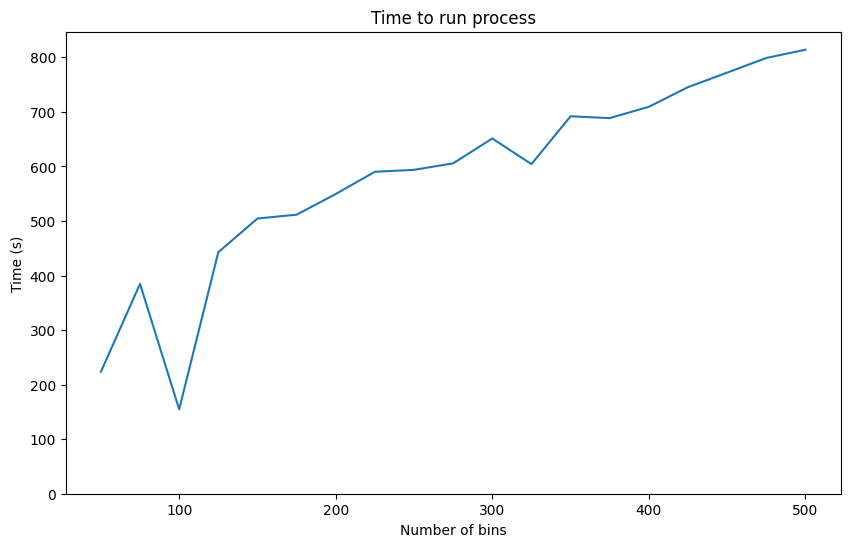

In [64]:
plt.figure(figsize=(10, 6))
plt.plot(POINTS[:, 0], process_times)
plt.xlabel('Number of bins')
plt.ylabel('Time (s)')
plt.title('Time to run process')
plt.ylim(0,)
plt.show()

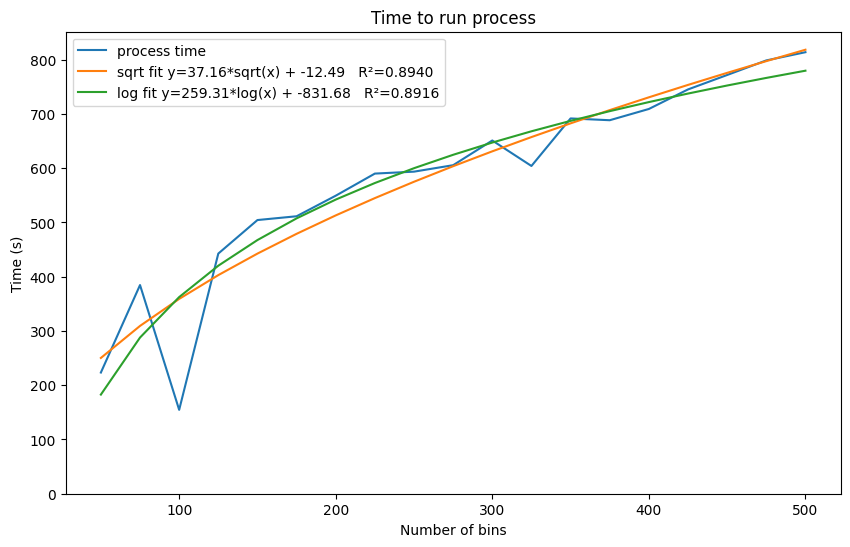

In [65]:
plt.figure(figsize=(10, 6))
plt.plot(POINTS[:, 0], process_times, label='process time')
plt.plot(POINTS[:, 0], sqrt_func(POINTS[:, 0], *sqrt_params), label='sqrt fit y=%.2f*sqrt(x) + %.2f   R²=%.4f' % (*tuple(sqrt_params), sqrt_r_squared))
plt.plot(POINTS[:, 0], log_func(POINTS[:, 0], *log_params), label='log fit y=%.2f*log(x) + %.2f   R²=%.4f' % (*tuple(log_params), log_r_squared))
plt.legend()
plt.xlabel('Number of bins')
plt.ylabel('Time (s)')
plt.title('Time to run process')
plt.ylim(0,)
plt.show()

In [66]:
# 20 norms vs 20 splines and 10 norms vs 10 splines to see if they take the same time to run with the same number of bins
# Also check if repeating the same name for splines could work

tags = np.array(['pulltest_10norm', 'pulltest_20norm', 'pulltest_10repeat_spline', 'pulltest_20repeat_spline', 'pulltest_10spline', 'pulltest_20spline'])

pulltest_process_times = np.array([])
pulltest_fill_spectra_times = np.array([])
pulltest_chi2_with_grad_times = np.array([])

for tag in tags:
    with open(f'./scaling_outputs/scale_{tag}.txt', 'r') as f:
        lines = f.readlines()
        for line in lines:
            if 'fillspectra_vary_all' in line:
                line_arr = line.split()
                time = float(line_arr[-1].split('=')[-1])
                pulltest_fill_spectra_times = np.append(pulltest_fill_spectra_times, time)
            elif 'metric_grad_vary_all' in line:
                line_arr = line.split()
                time = float(line_arr[-1].split('=')[-1])
                pulltest_chi2_with_grad_times = np.append(pulltest_chi2_with_grad_times, time)
    f.close()

    with open(f'./time_logs/user_{tag}_time.txt', 'r') as f2:
        line = f2.readline()
        time = float(line.split()[1].split('m')[0]) * 60 + float(line.split()[1].split('m')[1].split('s')[0])
        pulltest_process_times = np.append(pulltest_process_times, time)
    f2.close()

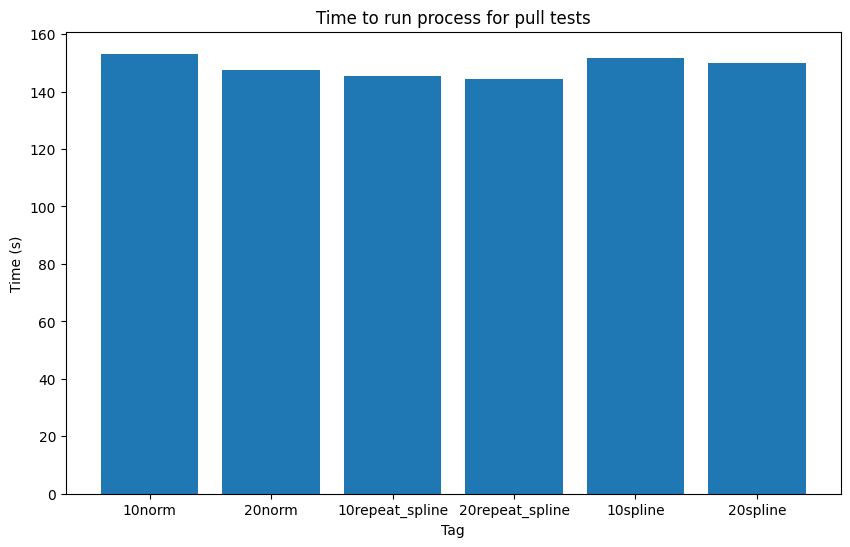

In [67]:
plt.figure(figsize=(10, 6))
plt.bar([t[9:] for t in tags], pulltest_process_times)
plt.xlabel('Tag')
plt.ylabel('Time (s)')
plt.title('Time to run process for pull tests')
plt.ylim(0,)
plt.show()

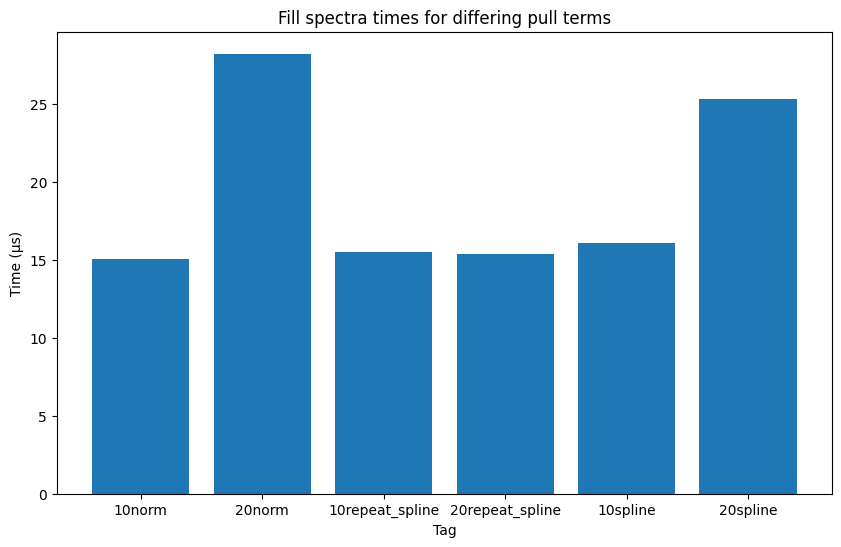

In [68]:
plt.figure(figsize=(10, 6))
plt.bar([t[9:] for t in tags], pulltest_fill_spectra_times)
plt.xlabel('Tag')
plt.ylabel('Time (μs)')
plt.title('Fill spectra times for differing pull terms')
plt.ylim(0,)
plt.show()

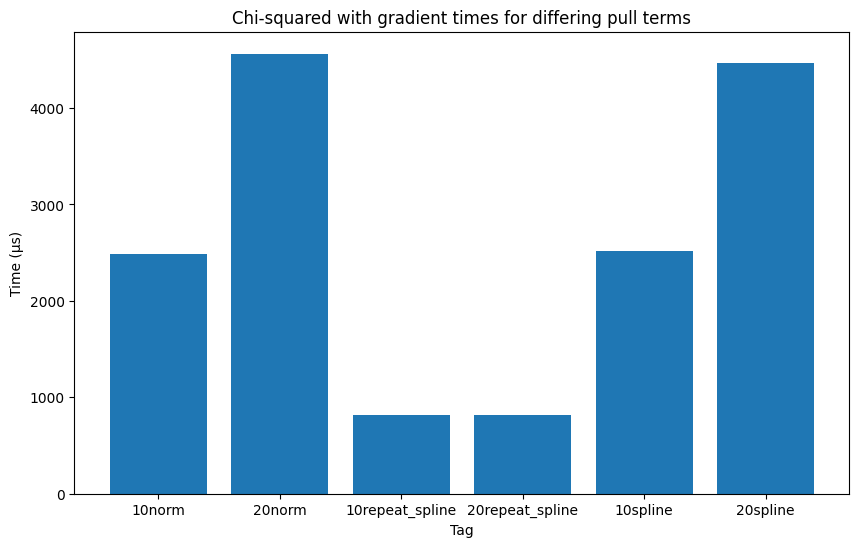

In [69]:
plt.figure(figsize=(10, 6))
plt.bar([t[9:] for t in tags], pulltest_chi2_with_grad_times)
plt.xlabel('Tag')
plt.ylabel('Time (μs)')
plt.title('Chi-squared with gradient times for differing pull terms')
plt.ylim(0,)
plt.show()

In [70]:
pull_points = np.array([(100,10), (100,20), (100,25), (100,30), (100,40), (100,50), (100,60), (100,70), (100,75), (100,80), 
                        (100,90), (100,100), (100,110), (100,120), (100,125), (100,130), (100,140), (100,150), (100,175), 
                        (100,200), (100,225), (100,250), (100,275), (100,300), (100,325), (100,350), (100,375), (100,400)])

In [71]:
vary_pull_process_times = np.array([])
vary_pull_fill_spectra_times = np.array([])
vary_pull_chi2_with_grad_times = np.array([])

for bins, pulls in pull_points:
    with open(f'./scaling_outputs/scale_{bins}bins_{pulls}pulls.txt', 'r') as f:
        lines = f.readlines()
        for line in lines:
            if 'fillspectra_vary_all' in line:
                line_arr = line.split()
                time = float(line_arr[-1].split('=')[-1])
                vary_pull_fill_spectra_times = np.append(vary_pull_fill_spectra_times, time)
            elif 'metric_grad_vary_all' in line:
                line_arr = line.split()
                time = float(line_arr[-1].split('=')[-1])
                vary_pull_chi2_with_grad_times = np.append(vary_pull_chi2_with_grad_times, time)
    f.close()

    with open(f'./time_logs/user_{bins}bins_{pulls}pulls_time.txt', 'r') as f2:
        line = f2.readline()
        time = float(line.split()[1].split('m')[0]) * 60 + float(line.split()[1].split('m')[1].split('s')[0])
        vary_pull_process_times = np.append(vary_pull_process_times, time)
    f2.close()

In [75]:
def linear_func(x, a, b):
    return a * x + b

spec_linear_params, spec_linear_covar = curve_fit(linear_func, pull_points[:, 1], vary_pull_fill_spectra_times)
spec_linear_residuals = vary_pull_fill_spectra_times - linear_func(pull_points[:, 1], *spec_linear_params)
spec_linear_ss_res = np.sum(spec_linear_residuals**2)
spec_linear_ss_tot = np.sum((vary_pull_fill_spectra_times - np.mean(vary_pull_fill_spectra_times))**2)
spec_linear_r_squared = 1 - (spec_linear_ss_res / spec_linear_ss_tot)

chi_linear_params, chi_linear_covar = curve_fit(linear_func, pull_points[:, 1], vary_pull_chi2_with_grad_times)
chi_linear_residuals = vary_pull_chi2_with_grad_times - linear_func(pull_points[:, 1], *chi_linear_params)
chi_linear_ss_res = np.sum(chi_linear_residuals**2)
chi_linear_ss_tot = np.sum((vary_pull_chi2_with_grad_times - np.mean(vary_pull_chi2_with_grad_times))**2)
chi_linear_r_squared = 1 - (chi_linear_ss_res / chi_linear_ss_tot)

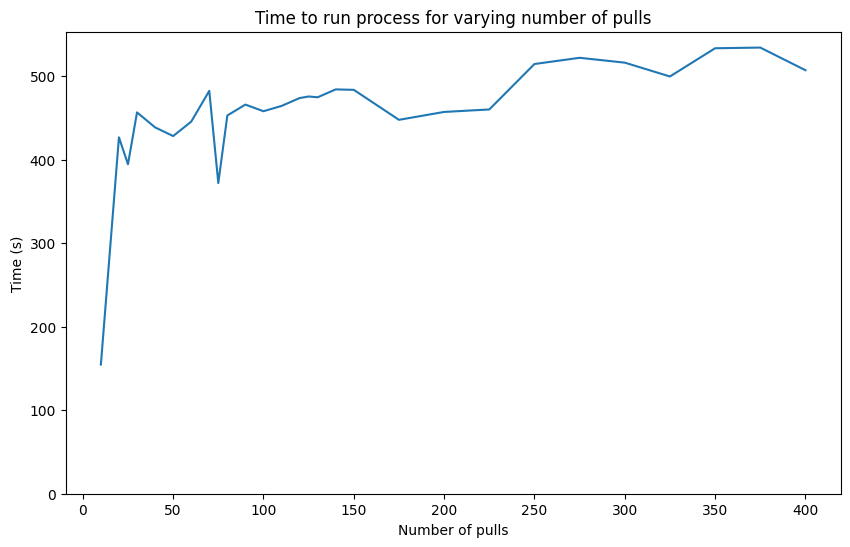

In [72]:
plt.figure(figsize=(10, 6))
plt.plot(pull_points[:, 1], vary_pull_process_times)
plt.xlabel('Number of pulls')
plt.ylabel('Time (s)')
plt.title('Time to run process for varying number of pulls')
plt.ylim(0,)
plt.show()

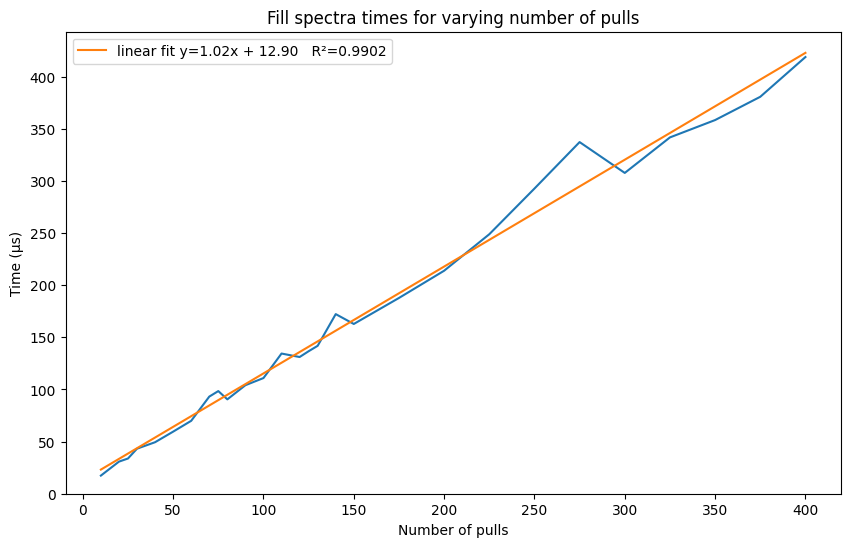

In [76]:
plt.figure(figsize=(10, 6))
plt.plot(pull_points[:, 1], vary_pull_fill_spectra_times)
plt.plot(pull_points[:, 1], linear_func(pull_points[:, 1], *spec_linear_params), label='linear fit y=%.2fx + %.2f   R²=%.4f' % (*tuple(spec_linear_params), spec_linear_r_squared))
plt.legend()
plt.xlabel('Number of pulls')
plt.ylabel('Time (μs)')
plt.title('Fill spectra times for varying number of pulls')
plt.ylim(0,)
plt.show()

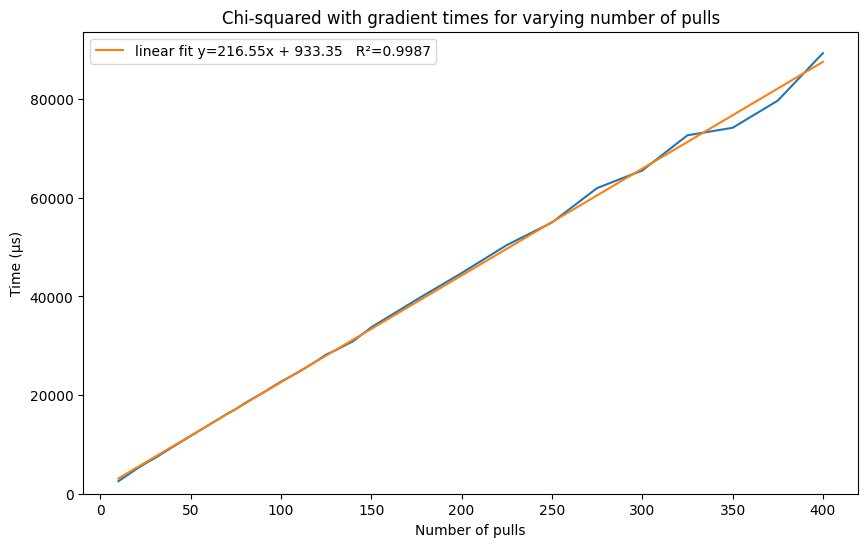

In [77]:
plt.figure(figsize=(10, 6))
plt.plot(pull_points[:, 1], vary_pull_chi2_with_grad_times)
plt.plot(pull_points[:, 1], linear_func(pull_points[:, 1], *chi_linear_params), label='linear fit y=%.2fx + %.2f   R²=%.4f' % (*tuple(chi_linear_params), chi_linear_r_squared))
plt.legend()
plt.xlabel('Number of pulls')
plt.ylabel('Time (μs)')
plt.title('Chi-squared with gradient times for varying number of pulls')
plt.ylim(0,)
plt.show()